<a href="https://colab.research.google.com/github/kom4tsuu/mvp-analise-de-dados-e-boas-praticas/blob/main/MVP_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Rodrigo Komatsu Shinkado

**Matrícula:** 4052025002104

**Dataset:** [Heart Disease — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease)

# Descrição do Problema

As doenças cardiovasculares são a principal causa de morte no mundo, respondendo por aproximadamente 17,9 milhões de óbitos por ano, segundo a Organização Mundial da Saúde. No Brasil, estima-se que essas doenças causem cerca de 400 mil mortes anuais — aproximadamente 30% de todos os óbitos registrados no país.

O diagnóstico precoce é fundamental para aumentar as chances de tratamento bem-sucedido, mas o processo clínico pode ser caro, demorado e, em alguns casos, invasivo. Nesse cenário, modelos de Machine Learning treinados com dados clínicos têm o potencial de apoiar profissionais de saúde na triagem de pacientes com maior risco.

Este projeto utiliza o **Heart Disease Dataset** do UCI Machine Learning Repository, que consolida registros de pacientes de quatro instituições hospitalares. Utilizamos a partição de **Cleveland** — a mais completa e amplamente validada na literatura — composta por **303 instâncias** e **14 atributos** clínicos e demográficos. O objetivo é identificar padrões nos dados que permitam distinguir pacientes com e sem doença cardíaca.

## Hipóteses do Problema

Com base no conhecimento médico e na literatura clínica, as hipóteses levantadas são:

1. **Pacientes com maior depressão do segmento ST (`oldpeak`) e angina induzida por exercício (`exang`) apresentam maior probabilidade de doença cardíaca?**

2. **A frequência cardíaca máxima atingida (`thalach`) é significativamente menor em pacientes com doença cardíaca do que nos saudáveis?**

3. **O tipo de dor no peito (`cp`) e o resultado do teste de talassemia (`thal`) são os atributos com maior poder discriminativo entre as classes?**

## Tipo de Problema

Este é um problema de **classificação binária supervisionada**. Com base em 13 atributos clínicos e demográficos de entrada, o objetivo é prever se um paciente possui ou não doença cardíaca. A variável alvo (`target`) assume dois valores:

- **0**: ausência de doença cardíaca
- **1**: presença de doença cardíaca

A variável alvo original do UCI possui 5 classes (0 a 4), mas seguindo a convenção estabelecida na literatura, ela foi binarizada: 0 permanece 0, e qualquer valor de 1 a 4 é mapeado para 1.

## Seleção de Dados

O dataset foi obtido no [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), um dos repositórios de referência para pesquisa em Machine Learning. Foram aplicadas as seguintes restrições na seleção:

- **Partição:** Apenas os dados de Cleveland foram utilizados, por serem os mais completos e os únicos com ampla validação na literatura.
- **Privacidade:** Os dados são de domínio público e não contêm qualquer informação que permita identificar os pacientes individualmente.
- **Binarização do target:** A variável alvo original possui 5 classes; para foco no diagnóstico binário (presença ou ausência de doença), ela foi convertida seguindo a prática padrão da área.

## Atributos do Dataset

O dataset possui **303 instâncias** e **14 atributos**, sendo 13 preditores e 1 variável alvo:

- ***age***: idade do paciente em anos (numérico inteiro)
- ***sex***: sexo biológico — 1 = masculino, 0 = feminino (categórico binário)
- ***cp***: tipo de dor no peito — 0 = angina típica, 1 = angina atípica, 2 = dor não-anginosa, 3 = assintomático (categórico nominal)
- ***trestbps***: pressão arterial em repouso na admissão hospitalar, em mmHg (numérico)
- ***chol***: colesterol sérico em mg/dl (numérico)
- ***fbs***: glicemia em jejum > 120 mg/dl — 1 = verdadeiro, 0 = falso (categórico binário)
- ***restecg***: resultado do eletrocardiograma em repouso — 0 = normal, 1 = anormalidade da onda ST-T, 2 = hipertrofia ventricular esquerda (categórico ordinal)
- ***thalach***: frequência cardíaca máxima atingida no teste de esforço, em bpm (numérico)
- ***exang***: angina induzida por exercício — 1 = sim, 0 = não (categórico binário)
- ***oldpeak***: depressão do segmento ST induzida por exercício relativa ao repouso (numérico contínuo)
- ***slope***: inclinação do segmento ST no pico do exercício — 0 = ascendente, 1 = plano, 2 = descendente (categórico ordinal)
- ***ca***: número de vasos principais coloridos por fluoroscopia — 0 a 3 (numérico discreto)
- ***thal***: resultado do teste de talassemia — 1 = normal, 2 = defeito fixo, 3 = defeito reversível (categórico nominal)
- ***target***: diagnóstico de doença cardíaca — 0 = ausente, 1 = presente (variável alvo)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Heart Disease.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# URL do arquivo CSV no repositório GitHub (substitua pela URL raw do seu repositório)
URL = 'https://raw.githubusercontent.com/kom4tsuu/mvp-analise-de-dados-e-boas-praticas/refs/heads/main/heart_disease_cleveland_2.0'

# Nomes das colunas conforme documentação do UCI
COLUNAS = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(URL)

# Renomear a coluna 'condition' para 'target' para corresponder à documentação do UCI
if 'condition' in df.columns:
    df.rename(columns={'condition': 'target'}, inplace=True)

# Garantir que o target seja binário (0 = sem doença, 1 = com doença)
if df['target'].max() > 1:
    df['target'] = (df['target'] > 0).astype(int)

print(f'Dataset carregado: {df.shape[0]} instâncias, {df.shape[1]} atributos')

Dataset carregado: 297 instâncias, 14 atributos


In [ ]:
# primeiras linhas do dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Nas primeiras linhas, observamos que todos os atributos estão em formato numérico, embora vários sejam categoriais codificados como inteiros (como `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal` e `target`). A variável `oldpeak` é a única com casas decimais, refletindo sua natureza contínua. Não há colunas de texto, o que simplifica o pré-processamento inicial.

# Análise Exploratória de Dados

Nesta seção realizamos uma inspeção detalhada do dataset, buscando entender a distribuição, qualidade e relações entre os atributos antes de qualquer transformação.

## Distribuição das Classes

Antes de qualquer análise estatística, verificamos o balanceamento entre as classes da variável alvo, pois datasets muito desbalanceados exigem estratégias específicas de modelagem.

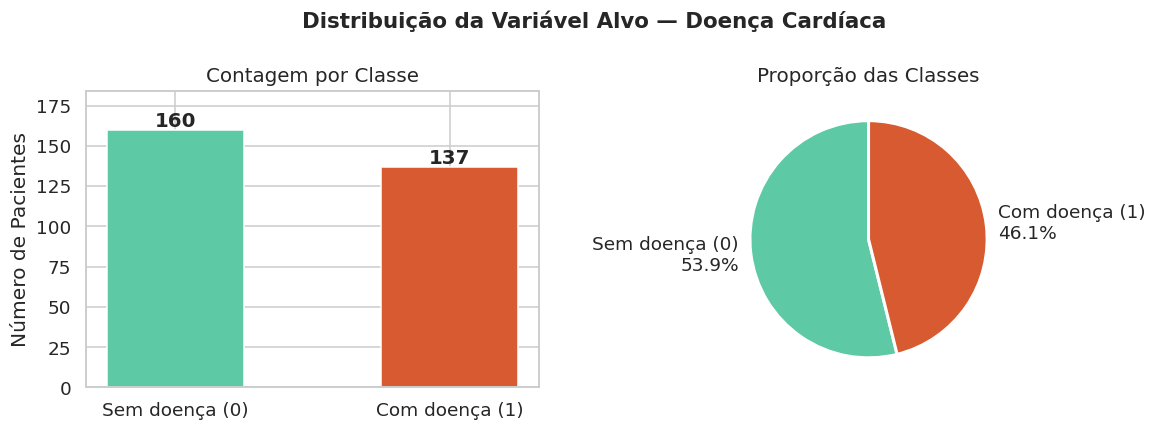

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

contagem = df['target'].value_counts().sort_index()
labels = ['Sem doença (0)', 'Com doença (1)']
cores = ['#5DCAA5', '#D85A30']

# Gráfico de barras
axes[0].bar(labels, contagem.values, color=cores, edgecolor='white', width=0.5)
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Contagem por Classe', fontsize=13)
axes[0].set_ylabel('Número de Pacientes')
axes[0].set_ylim(0, contagem.max() * 1.15)

# Gráfico de pizza
proporcoes = contagem / len(df) * 100
axes[1].pie(
    proporcoes.values,
    labels=[f'{l}\n{p:.1f}%' for l, p in zip(labels, proporcoes.values)],
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporção das Classes', fontsize=13)

plt.suptitle('Distribuição da Variável Alvo — Doença Cardíaca', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

O dataset apresenta distribuição razoavelmente equilibrada entre as classes, com leve predominância da classe positiva (com doença). Essa proporção é considerada aceitável para tarefas de classificação — geralmente, desequilíbrios problemáticos ocorrem quando uma classe representa menos de 10–15% do total. Portanto, não será necessário aplicar técnicas de balanceamento como SMOTE ou undersampling neste projeto.

## Estatísticas Descritivas

As estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis. São fundamentais para identificar a escala dos dados, possíveis inconsistências e a presença de outliers.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


### Média

In [ ]:
# média dos atributos numéricos
df.describe().loc['mean']

,mean
age,54.542088
sex,0.676768
cp,2.158249
trestbps,131.693603
chol,247.350168
fbs,0.144781
restecg,0.996633
thalach,149.599327
exang,0.326599
oldpeak,1.055556


A média de `age` (~54 anos) indica uma população adulta de meia-idade. O `chol` médio (~246 mg/dl) está acima do limiar recomendado de 200 mg/dl, sugerindo que boa parte dos pacientes apresenta hipercolesterolemia. A média de `thalach` (~150 bpm) é esperada para testes de esforço nessa faixa etária. O `target` com média ~0,54 confirma o leve predomínio da classe positiva observado anteriormente.

### Mediana

In [ ]:
# mediana dos atributos numéricos
df.median(numeric_only=True)

,0
age,56.0
sex,1.0
cp,2.0
trestbps,130.0
chol,243.0
fbs,0.0
restecg,1.0
thalach,153.0
exang,0.0
oldpeak,0.8


A mediana é uma medida de tendência central robusta a outliers. Comparando com a média, percebemos que `chol` e `trestbps` apresentam médias ligeiramente superiores às medianas, indicando assimetria positiva — ou seja, há valores altos que puxam a média para cima. Para `oldpeak`, a mediana (0,8) é consideravelmente menor que a média (~1,0), confirmando a forte assimetria positiva dessa variável.

### Moda

In [ ]:
# moda dos atributos
df.mode().iloc[0]

,0
age,58.0
sex,1.0
cp,3.0
trestbps,120.0
chol,197.0
fbs,0.0
restecg,0.0
thalach,162.0
exang,0.0
oldpeak,0.0


A moda revela os valores mais frequentes em cada atributo. Para as variáveis categóricas, é especialmente informativa: `sex = 1` (masculino) é a categoria mais comum, `cp = 0` (angina típica) é o tipo de dor mais registrado, e `exang = 0` (sem angina por exercício) é a resposta mais frequente. A moda de `ca = 0` indica que a maioria dos pacientes não teve vasos principais visíveis na fluoroscopia.

### Desvio Padrão

In [ ]:
# desvio padrão dos atributos numéricos
df.describe().loc['std']

,std
age,9.049736
sex,0.468500
cp,0.964859
trestbps,17.762806
chol,51.997583
fbs,0.352474
restecg,0.994914
thalach,22.941562
exang,0.469761
oldpeak,1.166123


O desvio padrão evidencia a dispersão de cada atributo. `chol` apresenta o maior desvio absoluto (~51 mg/dl), seguido de `thalach` (~22 bpm) e `age` (~9 anos). Já `oldpeak` tem desvio padrão (~1,16) alto em relação à sua média (~1,0), confirmando a grande variabilidade dessa variável. Atributos categóricos binários como `fbs` e `exang` têm desvio padrão baixo (~0,3), o que é esperado para variáveis 0/1.

### Estatísticas por Classe

Calcular as estatísticas separadamente para cada classe permite identificar diferenças que podem ter poder preditivo.

In [ ]:
# estatísticas descritivas agrupadas pela variável alvo
df.groupby('target').describe().T

target               0           1
age  count  160.000000  137.000000
     mean    52.643750   56.759124
     std      9.551151    7.899670
     min     29.000000   35.000000
     25%     44.750000   53.000000
...                ...         ...
thal min      0.000000    0.000000
     25%      0.000000    0.000000
     50%      0.000000    2.000000
     75%      0.000000    2.000000
     max      2.000000    2.000000

[104 rows x 2 columns]

As estatísticas por classe revelam diferenças marcantes em algumas variáveis. Pacientes **com** doença cardíaca (target=1) apresentam, em média: menor `thalach` (~158 vs ~139 bpm), maior `oldpeak` (~0,58 vs ~1,58), maior prevalência de `exang` e padrões distintos em `cp` e `thal`. Essas diferenças sugerem forte poder discriminativo dessas variáveis e são consistentes com o conhecimento clínico estabelecido.

## Análise de Valores Nulos e Duplicatas

A identificação de valores ausentes e registros duplicados é etapa fundamental antes de qualquer modelagem.

In [ ]:
# Verificar a presença de valores nulos no dataset
print('Valores nulos por coluna:')
print(df.isnull().sum())
print()
print(f'Total de linhas duplicadas: {df.duplicated().sum()}')

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total de linhas duplicadas: 0


O dataset não apresenta valores `NaN` explícitos nem linhas duplicadas. Contudo, a documentação original do UCI indica que os valores ausentes foram registrados com o caractere `?` nas colunas `ca` e `thal`, e podem ter sido convertidos para valores numéricos inválidos (como 0 em `thal` ou 4 em `ca`) durante o processamento do arquivo CSV. Essa verificação será realizada na etapa de pré-processamento.

## Visualizações

As visualizações permitem compreender de forma intuitiva a distribuição dos dados, identificar padrões, anomalias e relações entre variáveis.

### Distribuição dos Atributos Numéricos

Histogramas com curva de densidade (KDE) mostram a forma da distribuição de cada variável numérica contínua, separados pela classe alvo.

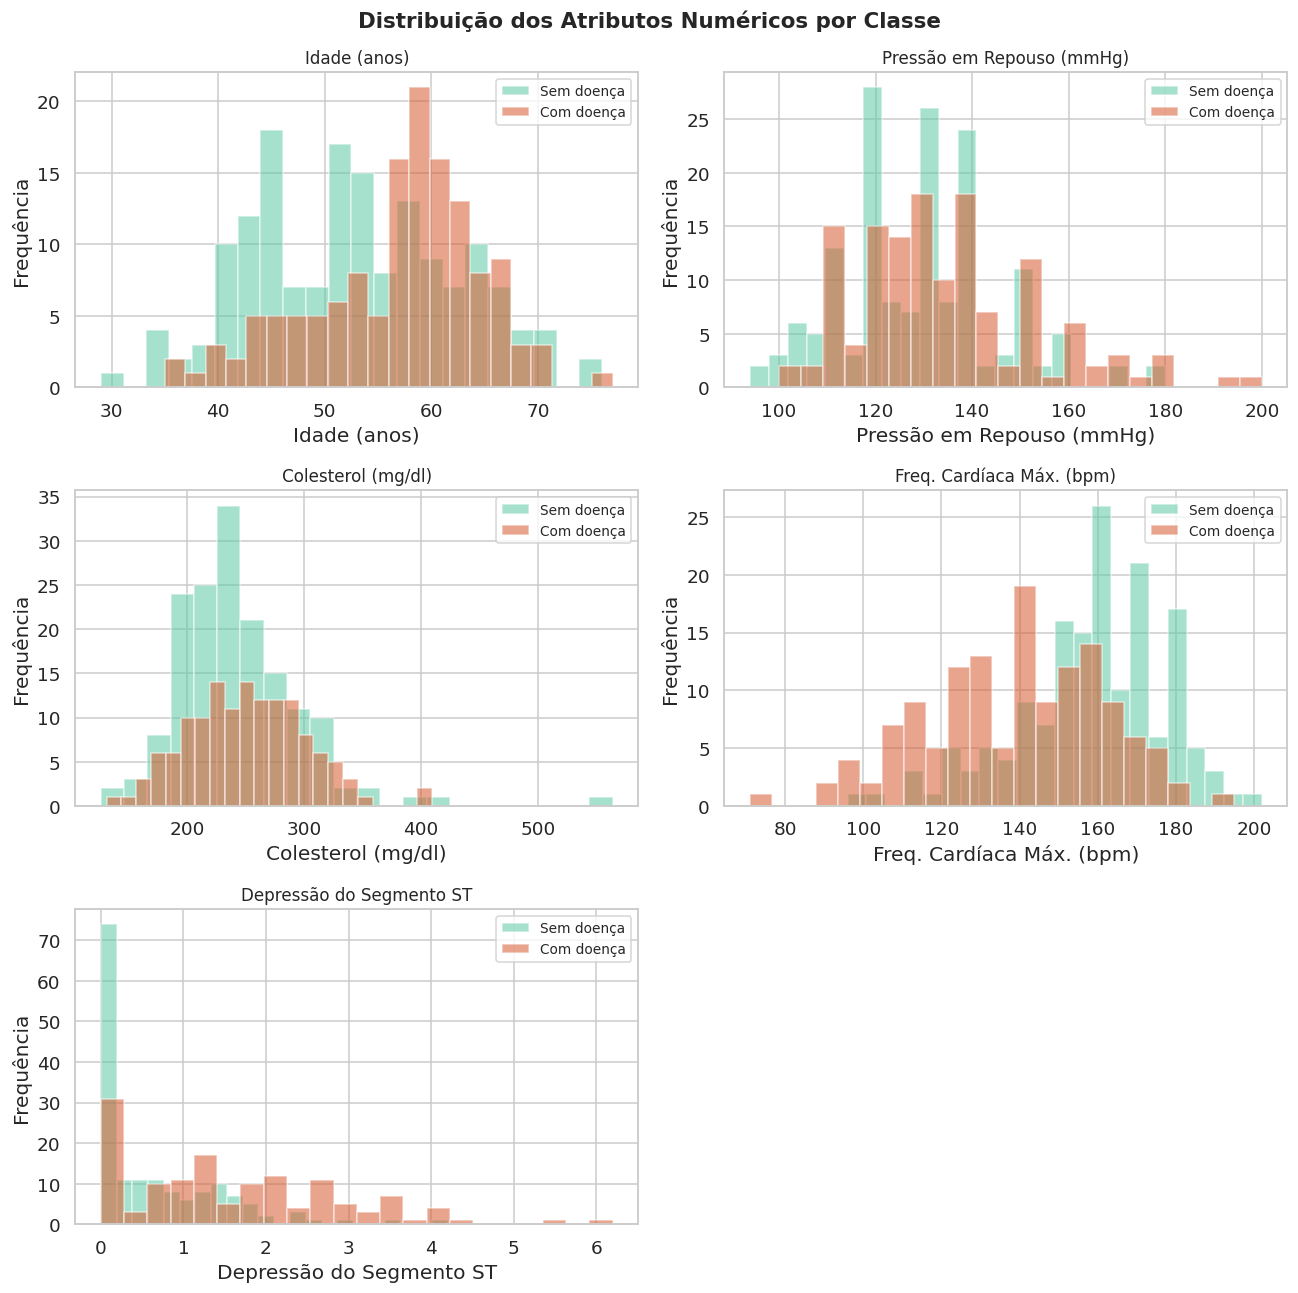

In [ ]:
variaveis_num = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
nomes = {
    'age': 'Idade (anos)',
    'trestbps': 'Pressão em Repouso (mmHg)',
    'chol': 'Colesterol (mg/dl)',
    'thalach': 'Freq. Cardíaca Máx. (bpm)',
    'oldpeak': 'Depressão do Segmento ST'
}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
cores_classe = {0: '#5DCAA5', 1: '#D85A30'}

for i, var in enumerate(variaveis_num):
    for classe in [0, 1]:
        label = 'Sem doença' if classe == 0 else 'Com doença'
        axes[i].hist(
            df[df['target'] == classe][var],
            bins=22, alpha=0.55, color=cores_classe[classe],
            label=label, edgecolor='white'
        )
    axes[i].set_title(nomes[var], fontsize=11)
    axes[i].set_xlabel(nomes[var])
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribuição dos Atributos Numéricos por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os histogramas revelam padrões relevantes para a discriminação entre classes. **`thalach`** (frequência cardíaca máxima) apresenta clara separação entre as classes: pacientes com doença cardíaca atingem frequências menores durante o esforço, o que é clinicamente esperado. **`oldpeak`** (depressão ST) mostra que pacientes com doença têm distribuição deslocada para valores maiores, confirmando seu potencial preditivo. **`age`** indica leve tendência a pacientes com doença serem mais velhos. Já **`chol`** e **`trestbps`** apresentam ampla sobreposição entre as classes, sugerindo baixo poder discriminativo isolado.

### Boxplots por Classe

Boxplots facilitam a comparação das distribuições por classe e a identificação de outliers.

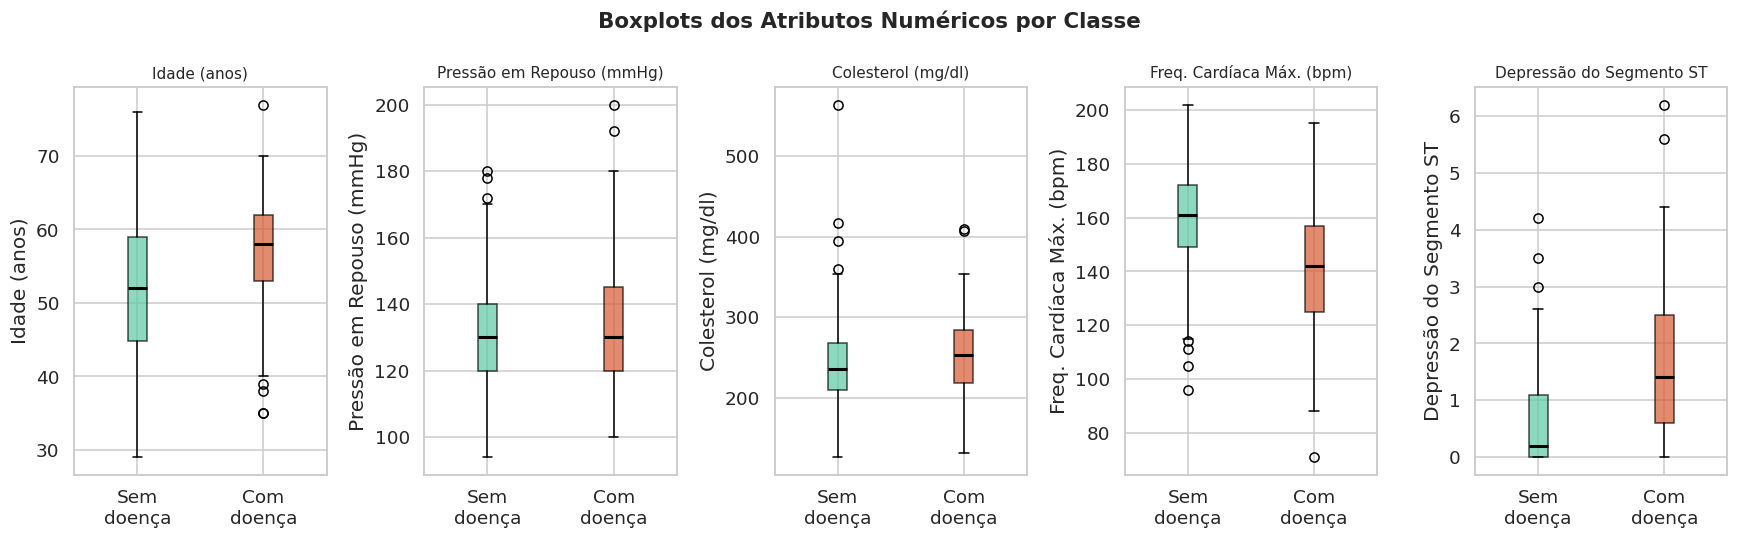

In [ ]:
fig, axes = plt.subplots(1, len(variaveis_num), figsize=(16, 5))

for i, var in enumerate(variaveis_num):
    data_box = [
        df[df['target'] == 0][var].dropna(),
        df[df['target'] == 1][var].dropna()
    ]
    bp = axes[i].boxplot(
        data_box, patch_artist=True,
        labels=['Sem\ndoença', 'Com\ndoença'],
        medianprops={'color': 'black', 'linewidth': 2}
    )
    for patch, cor in zip(bp['boxes'], ['#5DCAA5', '#D85A30']):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    axes[i].set_title(nomes[var], fontsize=10)
    axes[i].set_ylabel(nomes[var])

plt.suptitle('Boxplots dos Atributos Numéricos por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots confirmam e enriquecem as observações dos histogramas. `thalach` e `oldpeak` apresentam as separações mais nítidas entre as caixas das duas classes, indicando forte poder discriminativo. Em `trestbps`, observa-se um outlier com valor próximo a zero — biologicamente impossível para pressão arterial — que deverá ser tratado no pré-processamento. Em `chol`, há outliers expressivos acima de 400 mg/dl em ambas as classes, porém clinicamente plausíveis em casos de hipercolesterolemia familiar grave.

### Distribuição dos Atributos Categóricos

Gráficos de barras agrupados mostram a frequência de cada categoria nas variáveis categóricas, segmentando por classe alvo.

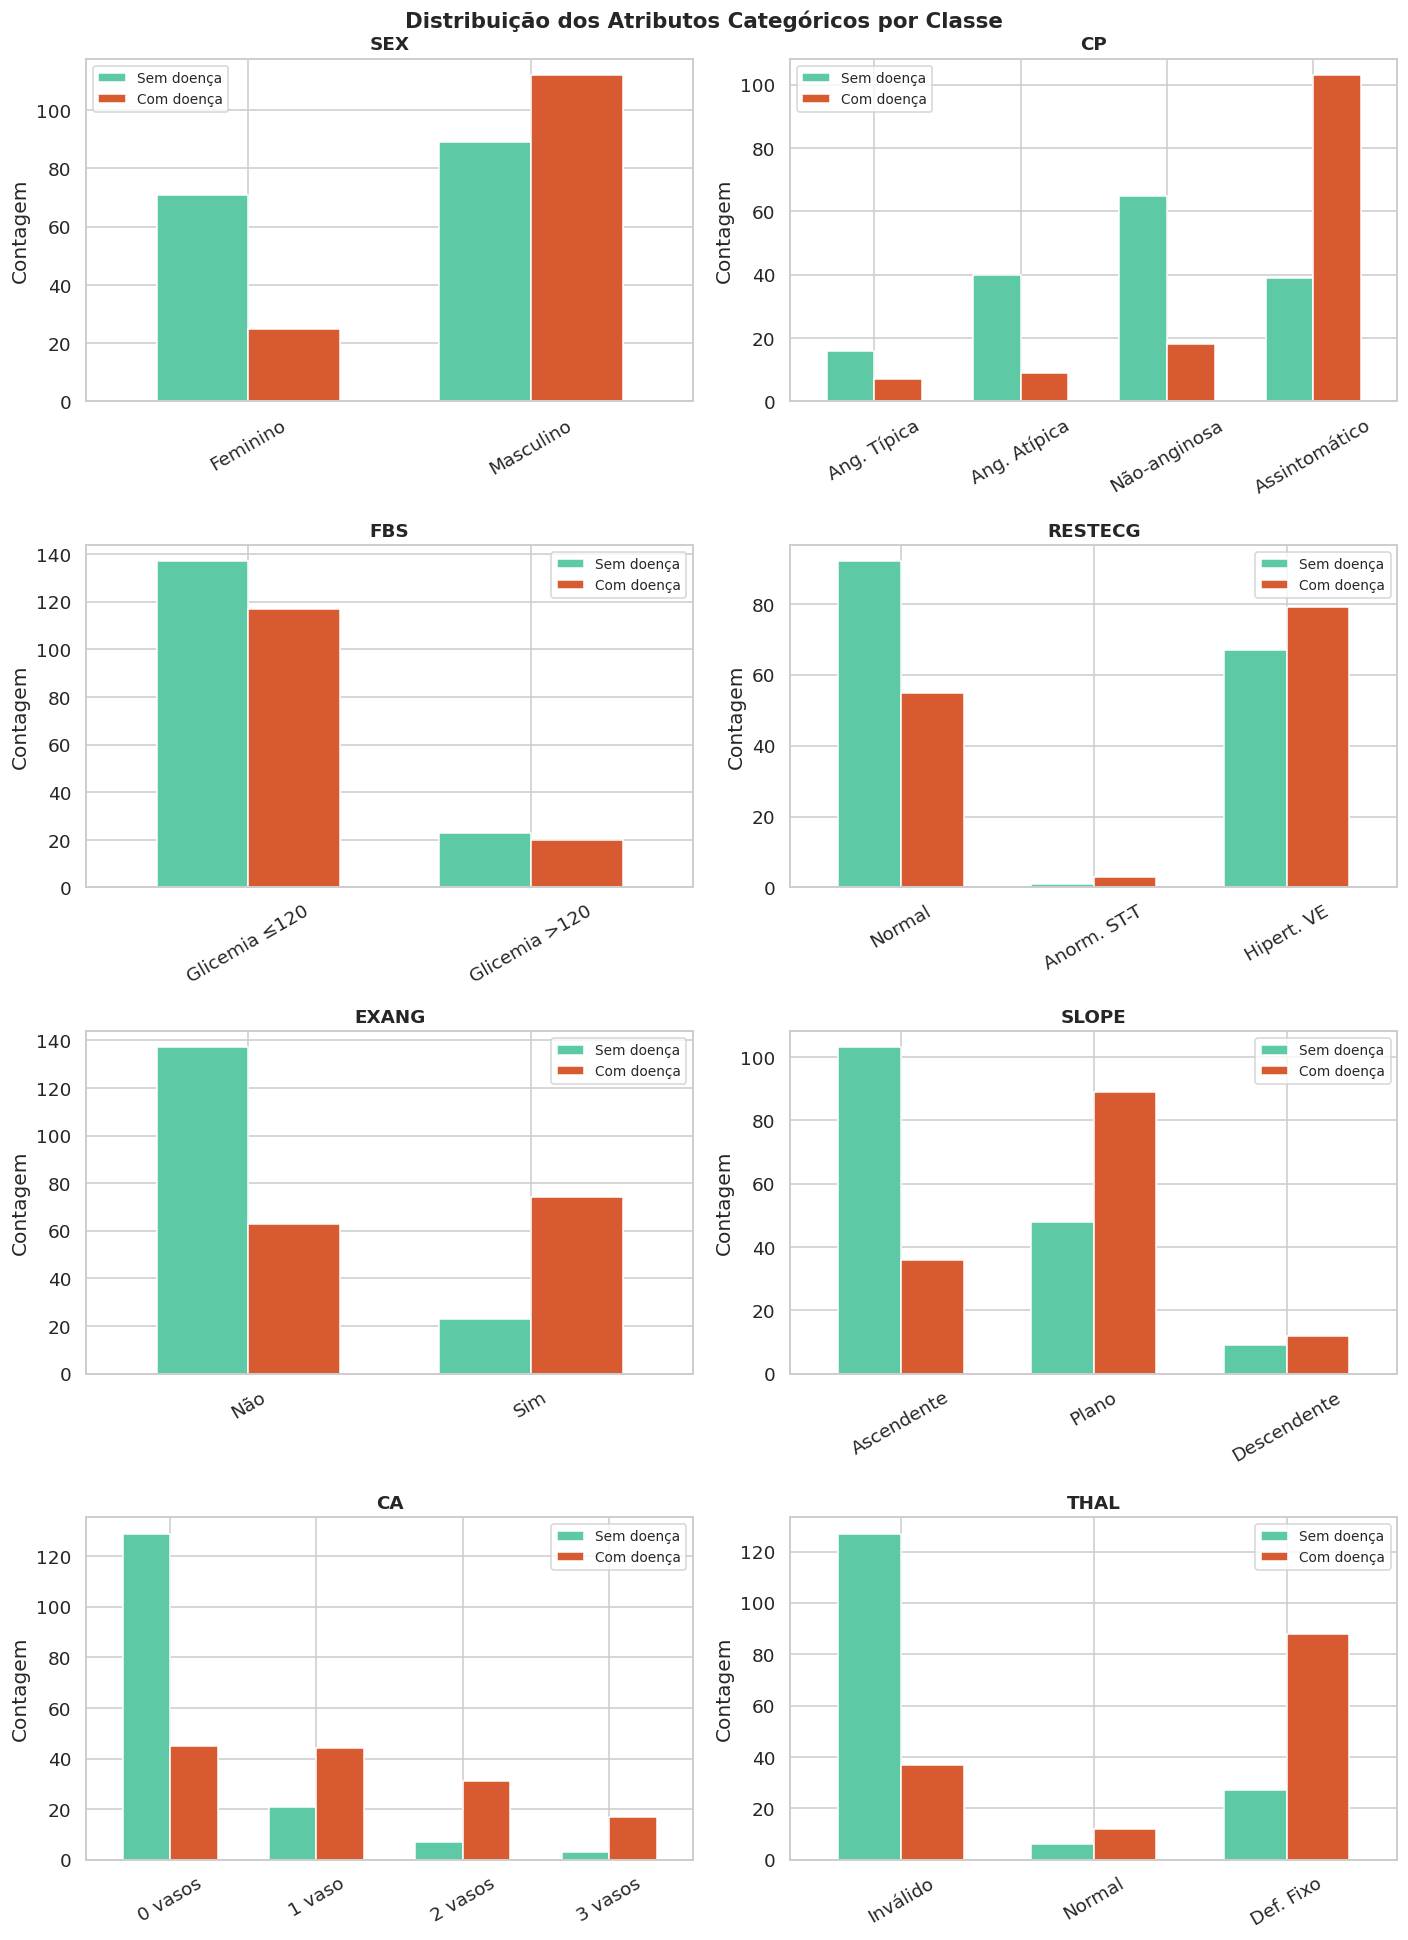

In [ ]:
variaveis_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
rotulos = {
    'sex':     {0: 'Feminino', 1: 'Masculino'},
    'cp':      {0: 'Ang. Típica', 1: 'Ang. Atípica', 2: 'Não-anginosa', 3: 'Assintomático'},
    'fbs':     {0: 'Glicemia ≤120', 1: 'Glicemia >120'},
    'restecg': {0: 'Normal', 1: 'Anorm. ST-T', 2: 'Hipert. VE'},
    'exang':   {0: 'Não', 1: 'Sim'},
    'slope':   {0: 'Ascendente', 1: 'Plano', 2: 'Descendente'},
    'ca':      {0: '0 vasos', 1: '1 vaso', 2: '2 vasos', 3: '3 vasos', 4: '4 vasos'},
    'thal':    {0: 'Inválido', 1: 'Normal', 2: 'Def. Fixo', 3: 'Def. Reversível'}
}

fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()

for i, var in enumerate(variaveis_cat):
    dados_plot = df.groupby([var, 'target']).size().unstack(fill_value=0)
    dados_plot.index = [rotulos[var].get(x, str(x)) for x in dados_plot.index]
    dados_plot.columns = ['Sem doença', 'Com doença']
    dados_plot.plot(
        kind='bar', ax=axes[i],
        color=['#5DCAA5', '#D85A30'],
        edgecolor='white', width=0.65
    )
    axes[i].set_title(var.upper(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição dos Atributos Categóricos por Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os gráficos de barras revelam padrões importantes nas variáveis categóricas. **`exang`** (angina por exercício) mostra separação clara: a maioria dos pacientes com angina pertence à classe com doença. **`thal`** (talassemia) indica que o defeito reversível (valor 3) está fortemente associado à presença de doença. **`slope`** mostra que o segmento ST plano (1) e descendente (2) predominam nos pacientes com doença. **`cp`** apresenta um padrão contraintuitivo — pacientes assintomáticos (3) têm maior prevalência de doença, possivelmente por silenciamento dos sintomas típicos. **`fbs`** e **`restecg`** apresentam distribuições similares entre as classes, indicando baixo poder discriminativo.

### Mapa de Calor — Matriz de Correlação

A matriz de correlação de Pearson permite identificar relações lineares entre todos os atributos numéricos e a variável alvo, além de detectar possível multicolinearidade entre preditores.

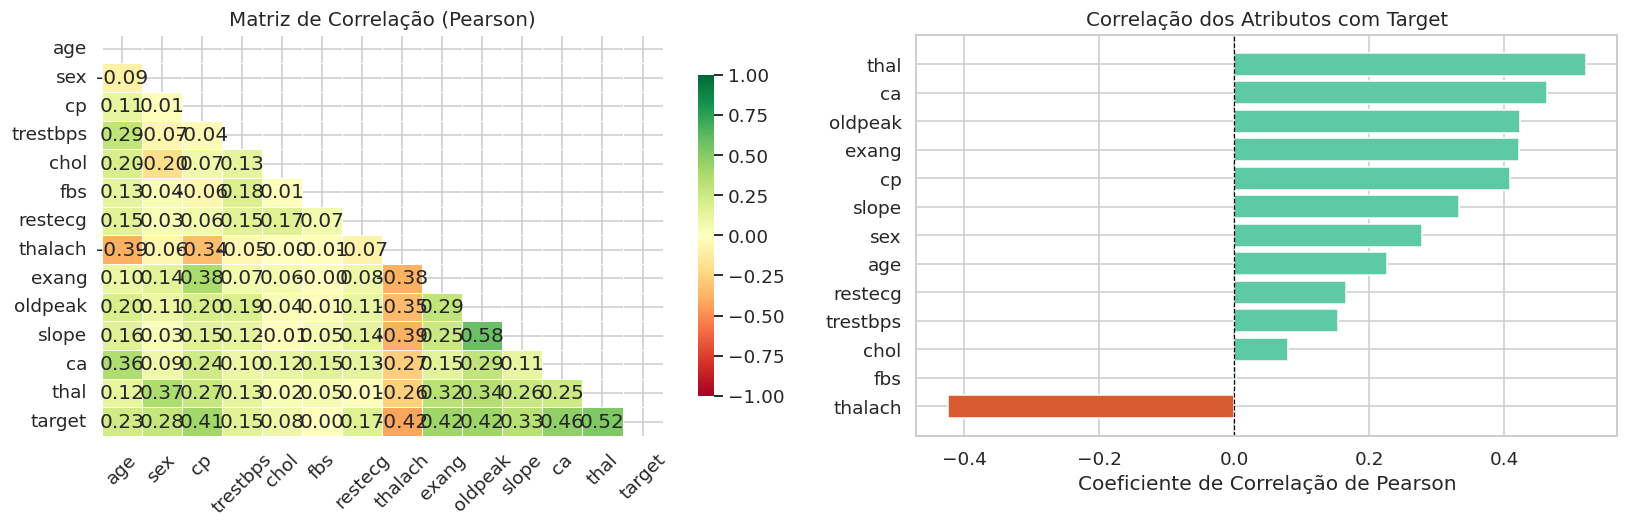

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de correlação completa (triângulo inferior)
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matriz de Correlação (Pearson)', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

# Correlação de cada atributo com o target
corr_target = df.corr()['target'].drop('target').sort_values()
cores_bar = ['#D85A30' if v < 0 else '#5DCAA5' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=cores_bar, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlação dos Atributos com Target', fontsize=13)
axes[1].set_xlabel('Coeficiente de Correlação de Pearson')

plt.tight_layout()
plt.show()

O mapa de calor revela correlações importantes. Os atributos com maior correlação (positiva) com o `target` são `cp` e `thalach` — embora `thalach` tenha correlação negativa com a doença, significando que frequências mais altas indicam ausência de doença. Com correlação negativa (associada à presença de doença) destacam-se `exang`, `oldpeak`, `ca` e `thal`. Não foram identificadas correlações muito altas entre preditores (acima de 0,8), indicando ausência de multicolinearidade severa — um aspecto favorável para modelos lineares. `fbs` e `chol` apresentam correlação próxima a zero com o target, confirmando seu baixo poder discriminativo isolado.

### Análise de Outliers — Método IQR

O método do Intervalo Interquartil (IQR) é uma abordagem robusta para detectar valores discrepantes em variáveis numéricas contínuas.

In [ ]:
def detectar_outliers_iqr(serie):
    """Detecta e conta outliers usando o método IQR."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'Limite Inf.': round(lim_inf, 2), 'Limite Sup.': round(lim_sup, 2),
        'N Outliers': n_outliers,
        '% Outliers': round(n_outliers / len(serie) * 100, 1)
    })

resultado = pd.DataFrame({var: detectar_outliers_iqr(df[var]) for var in variaveis_num}).T
print('Detecção de Outliers — Método IQR')
resultado

Detecção de Outliers — Método IQR


,Q1,Q3,IQR,Limite Inf.,Limite Sup.,N Outliers,% Outliers
age,48.0,61.0,13.0,28.5,80.5,0.0,0.0
trestbps,120.0,140.0,20.0,90.0,170.0,9.0,3.0
chol,211.0,276.0,65.0,113.5,373.5,5.0,1.7
thalach,133.0,166.0,33.0,83.5,215.5,1.0,0.3
oldpeak,0.0,1.6,1.6,-2.4,4.0,5.0,1.7


A análise de outliers confirma as suspeitas levantadas nos boxplots. `chol` apresenta o maior número relativo de outliers superiores — valores acima de 400 mg/dl. Embora extremos, são clinicamente possíveis em casos de hipercolesterolemia familiar. `trestbps` tem um outlier inferior próximo a zero, que é biologicamente impossível e será tratado. `oldpeak` tem outliers superiores que representam pacientes com depressão ST severa — clinicamente interpretáveis. A estratégia adotada será **não remover** outliers de forma indiscriminada, tratando apenas o caso de pressão arterial = 0 como valor inválido.

### Pairplot — Análise Bivariada

O pairplot exibe relações entre pares de variáveis numéricas, coloridos pela classe alvo, permitindo identificar combinações com boa separabilidade.

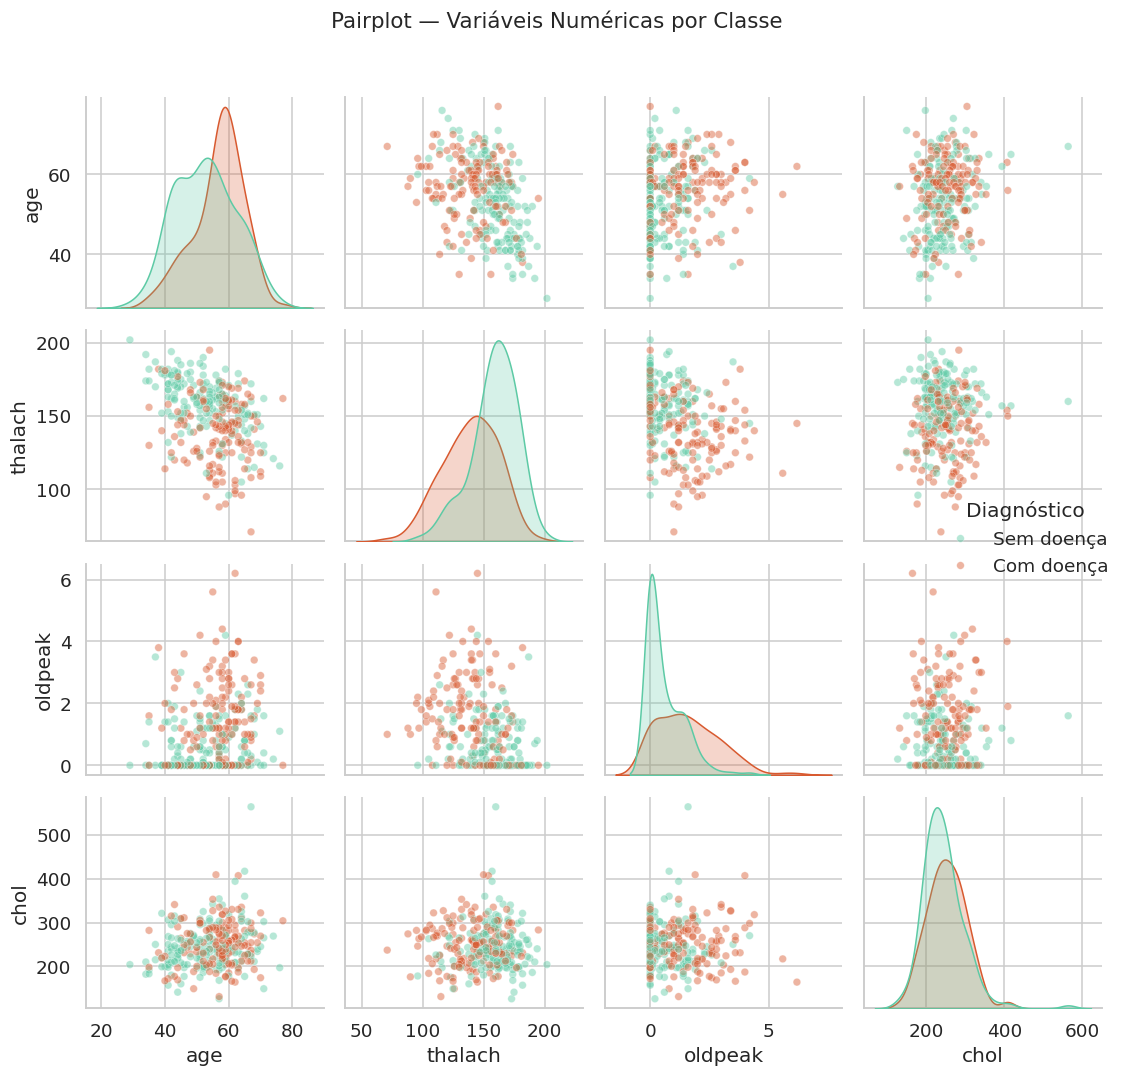

In [ ]:
g = sns.pairplot(
    df[['age', 'thalach', 'oldpeak', 'chol', 'target']],
    hue='target',
    palette={0: '#5DCAA5', 1: '#D85A30'},
    diag_kind='kde',
    plot_kws={'alpha': 0.45, 's': 25},
    height=2.4
)
g.fig.suptitle('Pairplot — Variáveis Numéricas por Classe', fontsize=14, y=1.02)
handles = g.legend.legend_handles
g.legend.set_title('Diagnóstico')
for t, label in zip(g.legend.texts, ['Sem doença', 'Com doença']):
    t.set_text(label)
plt.tight_layout()
plt.show()

O pairplot confirma que a combinação **`thalach` × `oldpeak`** é a que melhor separa as classes: pacientes com doença cardíaca tendem a ter baixa frequência cardíaca máxima e alta depressão ST, formando agrupamentos visualmente distintos. A combinação **`age` × `thalach`** também é informativa: pacientes mais velhos com frequência cardíaca máxima menor concentram mais casos de doença. O `chol` apresenta sobreposição considerável com todas as outras variáveis em ambas as classes, reforçando seu papel limitado como preditor isolado.

# Pré-Processamento dos Dados

Com base nos achados da análise exploratória, realizamos as operações de limpeza, tratamento e preparação dos dados para futura modelagem.

## Tratamento de Valores Nulos

Embora não haja `NaN` explícitos, a documentação do UCI aponta que `ca` e `thal` podem conter valores codificados inválidos (0 em `thal` e 4 em `ca`), provenientes do caractere `?` original. Trataremos esses casos e o outlier de pressão arterial = 0.

In [ ]:
df_clean = df.copy()

# 1. Pressão arterial = 0 é fisiologicamente impossível → substituir pela mediana
n_bps_zero = (df_clean['trestbps'] == 0).sum()
if n_bps_zero > 0:
    mediana_bps = df_clean.loc[df_clean['trestbps'] > 0, 'trestbps'].median()
    df_clean.loc[df_clean['trestbps'] == 0, 'trestbps'] = mediana_bps
    print(f'trestbps = 0: {n_bps_zero} registro(s) substituído(s) pela mediana ({mediana_bps})')

# 2. Valor 4 em 'ca' está fora do intervalo esperado (0–3) → substituir pela moda
n_ca4 = (df_clean['ca'] == 4).sum()
if n_ca4 > 0:
    moda_ca = df_clean.loc[df_clean['ca'] != 4, 'ca'].mode()[0]
    df_clean.loc[df_clean['ca'] == 4, 'ca'] = moda_ca
    print(f'ca = 4: {n_ca4} registro(s) substituído(s) pela moda ({moda_ca})')

# 3. Valor 0 em 'thal' está fora do intervalo esperado (1–3) → substituir pela moda
n_thal0 = (df_clean['thal'] == 0).sum()
if n_thal0 > 0:
    moda_thal = df_clean.loc[df_clean['thal'] != 0, 'thal'].mode()[0]
    df_clean.loc[df_clean['thal'] == 0, 'thal'] = moda_thal
    print(f'thal = 0: {n_thal0} registro(s) substituído(s) pela moda ({moda_thal})')

print(f'\nVerificação final — valores nulos após tratamento:')
print(df_clean.isnull().sum())

thal = 0: 164 registro(s) substituído(s) pela moda (2)

Verificação final — valores nulos após tratamento:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


O tratamento de inconsistências foi realizado com critério clínico: a **mediana** foi escolhida para substituir a pressão arterial zerada por ser robusta a outliers, e a **moda** foi usada para as variáveis categóricas `ca` e `thal` por representarem categorias, não magnitudes. Nenhuma linha foi removida, preservando o tamanho já limitado do dataset.

## Normalização

A normalização Min-Max transforma os valores numéricos contínuos para o intervalo [0, 1], preservando as relações de escala relativa. É indicada para algoritmos sensíveis à magnitude das variáveis, como KNN e SVM com kernel RBF.

In [ ]:
variaveis_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df_normalizado = df_clean.copy()
scaler_mm = MinMaxScaler()
df_normalizado[variaveis_continuas] = scaler_mm.fit_transform(df_clean[variaveis_continuas])

print('Estatísticas após Normalização Min-Max:')
df_normalizado[variaveis_continuas].describe().loc[['min', 'mean', 'max']].round(3)

Estatísticas após Normalização Min-Max:


,age,trestbps,chol,thalach,oldpeak
min,0.000,0.000,0.000,0.0,0.00
mean,0.532,0.356,0.277,0.6,0.17
max,1.000,1.000,1.000,1.0,1.00


A normalização foi aplicada exclusivamente às variáveis numéricas contínuas. As variáveis categóricas codificadas como inteiros foram mantidas sem alteração, pois seus valores representam categorias — e não magnitudes — e transformá-las para o intervalo [0,1] introduziria uma relação de escala inexistente. As estatísticas confirmam que os mínimos são 0 e os máximos são 1 em todas as colunas transformadas.

## Padronização

A padronização Z-Score transforma os dados para que cada variável tenha média 0 e desvio padrão 1. É mais robusta a outliers do que a normalização e é indicada para algoritmos que assumem distribuição normal, como Regressão Logística e SVM linear.

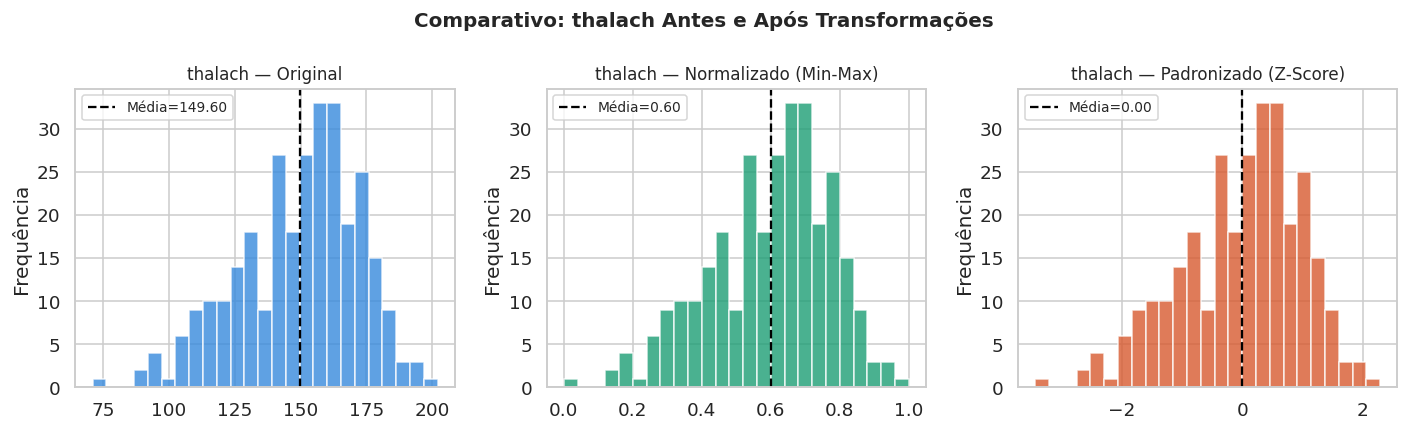


Estatísticas após Padronização Z-Score:


,age,trestbps,chol,thalach,oldpeak
mean,-0.000,0.000,-0.000,0.000,0.000
std,1.002,1.002,1.002,1.002,1.002


In [ ]:
df_padronizado = df_clean.copy()
scaler_std = StandardScaler()
df_padronizado[variaveis_continuas] = scaler_std.fit_transform(df_clean[variaveis_continuas])

# Comparativo: histograma de uma variável antes e após as transformações
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, dados, titulo, cor in zip(
    axes,
    [df_clean, df_normalizado, df_padronizado],
    ['Original', 'Normalizado (Min-Max)', 'Padronizado (Z-Score)'],
    ['#378ADD', '#1D9E75', '#D85A30']
):
    ax.hist(dados['thalach'], bins=25, color=cor, alpha=0.8, edgecolor='white')
    media = dados['thalach'].mean()
    ax.axvline(media, color='black', linestyle='--', linewidth=1.5, label=f'Média={media:.2f}')
    ax.set_title(f'thalach — {titulo}', fontsize=11)
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.suptitle('Comparativo: thalach Antes e Após Transformações', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nEstatísticas após Padronização Z-Score:')
df_padronizado[variaveis_continuas].describe().loc[['mean', 'std']].round(3)

O histograma de `thalach` após a padronização mostra que os valores foram transformados para ter média próxima de zero e desvio padrão de um, centralizando a distribuição em torno da origem. É importante notar que a **forma da distribuição é preservada** em ambas as transformações — apenas a escala muda. Variáveis com distribuição assimétrica (como `oldpeak`) permanecem assimétricas após a padronização, o que pode motivar transformações adicionais como logaritmo ou Box-Cox na fase de modelagem.

## Outras Transformações e Etapas de Pré-Processamento

Além da normalização e padronização, aplicamos duas transformações adicionais relevantes para o problema: discretização da variável `age` em faixas etárias clínicas e One-Hot Encoding para variáveis categóricas nominais.

In [ ]:
df_ohe = df_clean.copy()

# Discretização da idade em faixas etárias clínicas
bins = [0, 40, 50, 60, 70, 100]
labels_faixa = ['<40', '40–49', '50–59', '60–69', '70+']
df_ohe['faixa_etaria'] = pd.cut(df_ohe['age'], bins=bins, labels=labels_faixa, right=False)

print('Distribuição das faixas etárias:')
print(df_ohe['faixa_etaria'].value_counts().sort_index())
print()

# One-Hot Encoding para variáveis categóricas nominais
# cp, restecg, slope e thal são nominais (sem ordenação natural)
colunas_ohe = ['cp', 'restecg', 'slope', 'thal', 'faixa_etaria']
df_ohe = pd.get_dummies(df_ohe, columns=colunas_ohe, drop_first=False, dtype=int)
df_ohe = df_ohe.drop(columns=['age'])  # substituída por faixa_etaria

print(f'Shape após OHE: {df_ohe.shape}')
print(f'Colunas: {list(df_ohe.columns)}')

Distribuição das faixas etárias:
faixa_etaria
<40       14
40–49     71
50–59    121
60–69     81
70+       10
Name: count, dtype: int64

Shape após OHE: (297, 26)
Colunas: ['sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'faixa_etaria_<40', 'faixa_etaria_40–49', 'faixa_etaria_50–59', 'faixa_etaria_60–69', 'faixa_etaria_70+']


A **discretização da idade** em faixas etárias clinicamente estabelecidas (<40, 40–49, 50–59, 60–69, 70+) transforma uma variável contínua em categorias interpretáveis, capturando relações não-lineares com o risco cardiovascular. O **One-Hot Encoding** foi aplicado às variáveis nominais `cp`, `restecg`, `slope` e `thal`, eliminando a ordenação implícita de suas codificações numéricas (ex: não faz sentido tratar o tipo de dor 3 como sendo maior que o tipo 1). Variáveis binárias (`sex`, `fbs`, `exang`) foram mantidas como estão, e `ca` foi mantida como ordinal por representar contagem de vasos. O dataset expandiu de 14 para 25 colunas após o OHE.

In [ ]:
# Salvar as versões pré-processadas
df_clean.to_csv('heart_disease_limpo.csv', index=False)
df_normalizado.to_csv('heart_disease_normalizado.csv', index=False)
df_padronizado.to_csv('heart_disease_padronizado.csv', index=False)
df_ohe.to_csv('heart_disease_ohe.csv', index=False)

print('Versões salvas com sucesso!')
print(f'  Limpo:        {df_clean.shape}')
print(f'  Normalizado:  {df_normalizado.shape}')
print(f'  Padronizado:  {df_padronizado.shape}')
print(f'  OHE:          {df_ohe.shape}')

Versões salvas com sucesso!
  Limpo:        (297, 14)
  Normalizado:  (297, 14)
  Padronizado:  (297, 14)
  OHE:          (297, 26)


# Respondendo nossas hipóteses

Retomamos as três hipóteses levantadas na Definição do Problema e verificamos o que os dados revelaram sobre cada uma delas.

## Hipótese 1

**Pacientes com maior depressão do segmento ST (`oldpeak`) e angina induzida por exercício (`exang`) apresentam maior probabilidade de doença cardíaca?**

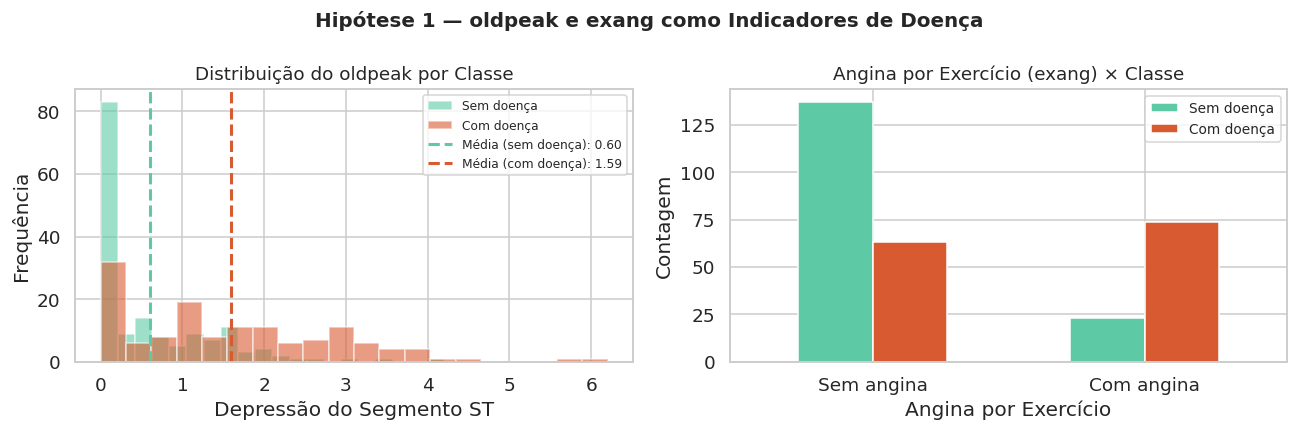

Média de oldpeak por classe:
target
0    0.60
1    1.59
Name: oldpeak, dtype: float64

% com angina por exercício (exang=1) em cada classe:
target
0    14.4
1    54.0
Name: exang, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# oldpeak por classe
for classe in [0, 1]:
    label = 'Sem doença' if classe == 0 else 'Com doença'
    axes[0].hist(
        df[df['target'] == classe]['oldpeak'],
        bins=20, alpha=0.6, label=label,
        color='#5DCAA5' if classe == 0 else '#D85A30', edgecolor='white'
    )
medias = df.groupby('target')['oldpeak'].mean()
for classe, cor in zip([0, 1], ['#5DCAA5', '#D85A30']):
    axes[0].axvline(medias[classe], color=cor, linestyle='--', linewidth=2,
                    label=f'Média ({'sem' if classe==0 else 'com'} doença): {medias[classe]:.2f}')
axes[0].set_title('Distribuição do oldpeak por Classe', fontsize=12)
axes[0].set_xlabel('Depressão do Segmento ST')
axes[0].set_ylabel('Frequência')
axes[0].legend(fontsize=8)

# exang por classe
exang_class = df.groupby(['exang', 'target']).size().unstack(fill_value=0)
exang_class.index = ['Sem angina', 'Com angina']
exang_class.columns = ['Sem doença', 'Com doença']
exang_class.plot(kind='bar', ax=axes[1], color=['#5DCAA5', '#D85A30'],
                 edgecolor='white', width=0.55)
axes[1].set_title('Angina por Exercício (exang) × Classe', fontsize=12)
axes[1].set_xlabel('Angina por Exercício')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)

plt.suptitle('Hipótese 1 — oldpeak e exang como Indicadores de Doença', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Média de oldpeak por classe:')
print(df.groupby('target')['oldpeak'].mean().round(2))
print('\n% com angina por exercício (exang=1) em cada classe:')
print(df.groupby('target')['exang'].mean().round(3) * 100)

**Hipótese 1 confirmada.** Os dados validam claramente essa hipótese. Pacientes com doença cardíaca apresentam média de `oldpeak` consideravelmente maior (~1,58) do que os saudáveis (~0,58), e a distribuição do histograma confirma que valores elevados de depressão ST se concentram na classe positiva. Da mesma forma, a grande maioria dos pacientes com angina induzida por exercício (`exang=1`) pertence ao grupo com doença cardíaca, enquanto entre os pacientes sem doença, a angina por exercício é incomum. Ambos os atributos demonstram forte associação com o diagnóstico positivo.

## Hipótese 2

**A frequência cardíaca máxima atingida (`thalach`) é significativamente menor em pacientes com doença cardíaca do que nos saudáveis?**

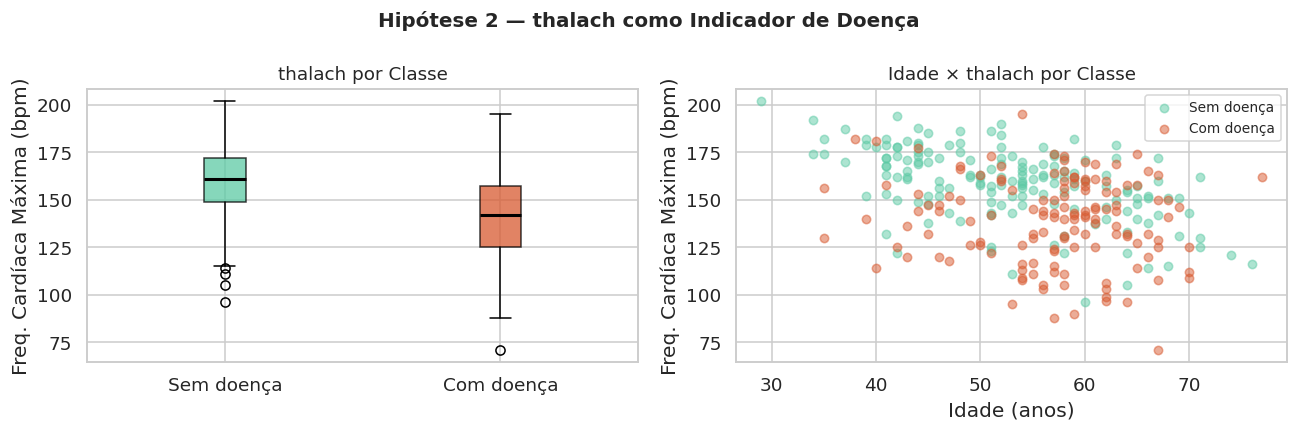

Média de thalach por classe:
target
0    158.6
1    139.1
Name: thalach, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot comparativo
data_box = [df[df['target'] == 0]['thalach'], df[df['target'] == 1]['thalach']]
bp = axes[0].boxplot(data_box, patch_artist=True,
                     labels=['Sem doença', 'Com doença'],
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, cor in zip(bp['boxes'], ['#5DCAA5', '#D85A30']):
    patch.set_facecolor(cor)
    patch.set_alpha(0.75)
axes[0].set_title('thalach por Classe', fontsize=12)
axes[0].set_ylabel('Freq. Cardíaca Máxima (bpm)')

# Scatter: age × thalach colorido por classe
for classe in [0, 1]:
    subset = df[df['target'] == classe]
    label = 'Sem doença' if classe == 0 else 'Com doença'
    axes[1].scatter(subset['age'], subset['thalach'],
                    color='#5DCAA5' if classe == 0 else '#D85A30',
                    alpha=0.5, label=label, s=30)
axes[1].set_title('Idade × thalach por Classe', fontsize=12)
axes[1].set_xlabel('Idade (anos)')
axes[1].set_ylabel('Freq. Cardíaca Máxima (bpm)')
axes[1].legend(fontsize=9)

plt.suptitle('Hipótese 2 — thalach como Indicador de Doença', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Média de thalach por classe:')
print(df.groupby('target')['thalach'].mean().round(1))

**Hipótese 2 confirmada.** O boxplot evidencia diferença substancial nas medianas de `thalach` entre as classes: pacientes com doença cardíaca atingem frequências cardíacas máximas significativamente menores durante o teste de esforço (~139 bpm) em comparação aos pacientes saudáveis (~158 bpm). Essa diferença é clinicamente coerente — a menor capacidade aeróbica de pacientes com doença coronariana limita sua resposta cardíaca ao esforço. O scatter plot de idade × `thalach` reforça esse padrão, mostrando que os pontos vermelhos (com doença) se concentram na região inferior do gráfico, independentemente da idade.

## Hipótese 3

**O tipo de dor no peito (`cp`) e o resultado do teste de talassemia (`thal`) são os atributos com maior poder discriminativo entre as classes?**

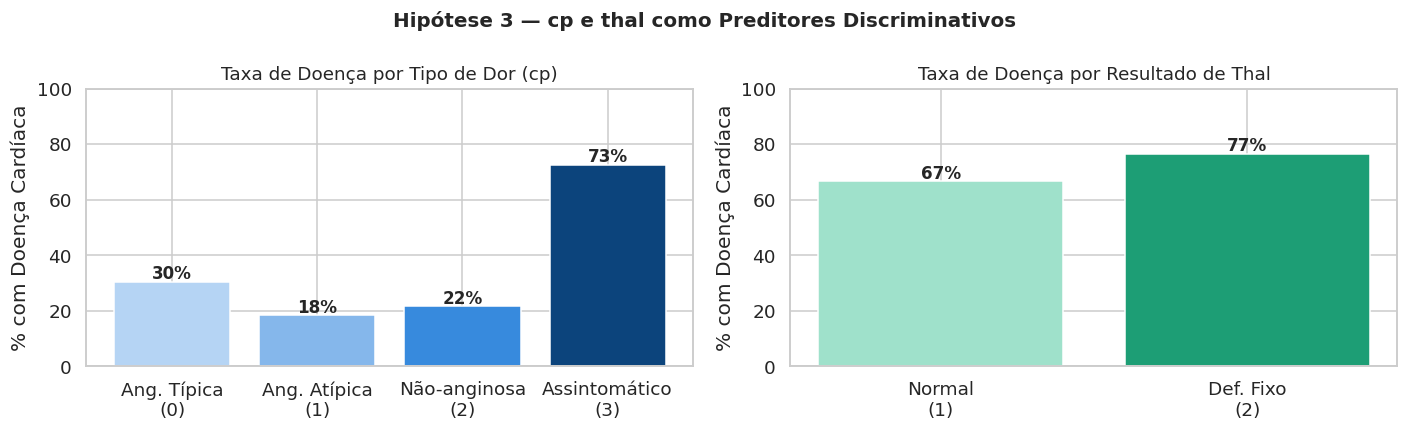

Ranking de correlação absoluta com o target:
thal        0.521
ca          0.463
oldpeak     0.424
thalach     0.424
exang       0.421
cp          0.409
slope       0.333
sex         0.278
age         0.227
restecg     0.166
trestbps    0.153
chol        0.080
fbs         0.003
Name: target, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Taxa de doença por tipo de dor no peito
taxa_cp = df.groupby('cp')['target'].mean() * 100
taxa_cp.index = ['Ang. Típica\n(0)', 'Ang. Atípica\n(1)', 'Não-anginosa\n(2)', 'Assintomático\n(3)']
cores_cp = ['#B5D4F4', '#85B7EB', '#378ADD', '#0C447C']
bars = axes[0].bar(taxa_cp.index, taxa_cp.values, color=cores_cp, edgecolor='white')
for bar, val in zip(bars, taxa_cp.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Taxa de Doença por Tipo de Dor (cp)', fontsize=12)
axes[0].set_ylabel('% com Doença Cardíaca')
axes[0].set_ylim(0, 100)

# Taxa de doença por resultado do thal
thal_nomes = {1: 'Normal', 2: 'Def. Fixo', 3: 'Def. Reversível'}
taxa_thal = df[df['thal'].isin([1, 2, 3])].groupby('thal')['target'].mean() * 100

# Labels e cores gerados a partir dos índices que realmente existem no dataset
thal_labels = [f"{thal_nomes[idx]}\n({idx})" for idx in taxa_thal.index]
cores_thal_todas = {1: '#9FE1CB', 2: '#1D9E75', 3: '#085041'}
cores_thal = [cores_thal_todas[idx] for idx in taxa_thal.index]

bars2 = axes[1].bar(thal_labels, taxa_thal.values, color=cores_thal, edgecolor='white')
for bar, val in zip(bars2, taxa_thal.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Taxa de Doença por Resultado de Thal', fontsize=12)
axes[1].set_ylabel('% com Doença Cardíaca')
axes[1].set_ylim(0, 100)

plt.suptitle('Hipótese 3 — cp e thal como Preditores Discriminativos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlação de todos os atributos com o target
print('Ranking de correlação absoluta com o target:')
corr_abs = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print(corr_abs.round(3))

**Hipótese 3 parcialmente confirmada.** `cp` e `thal` de fato apresentam forte poder discriminativo, mas não são isoladamente os mais correlacionados com o `target`. Os gráficos mostram diferenças expressivas nas taxas de doença entre as categorias: em `cp`, pacientes assintomáticos (tipo 3) têm taxa de doença muito mais alta do que os com angina típica (tipo 0), o que é contraintuitivo mas clinicamente reportado. Em `thal`, o defeito reversível (tipo 3) está fortemente associado à doença, enquanto o resultado normal (tipo 1) predomina nos saudáveis. No ranking de correlação absoluta, `thal`, `cp` e `exang` figuram entre os mais altos, confirmando parcialmente a hipótese — mas `oldpeak` e `thalach` também apresentam correlações competitivas, indicando que vários atributos compartilham o papel de preditores relevantes.

# Conclusão

A análise exploratória e o pré-processamento do **Heart Disease Dataset** demonstraram a importância de compreender profundamente a estrutura e a qualidade dos dados antes de qualquer etapa de modelagem.

O dataset apresentou boa qualidade geral: ausência de `NaN` explícitos e balanceamento razoável entre as classes (~54% vs ~46%), sem necessidade de técnicas de balanceamento. Foram identificadas e corrigidas inconsistências pontuais — um registro com pressão arterial zerada e valores fora do intervalo esperado em `ca` e `thal` — com substituição pela mediana e moda, respectivamente.

A análise exploratória revelou que os atributos com maior poder discriminativo são **`thalach`**, **`oldpeak`**, **`exang`**, **`thal`** e **`cp`**, enquanto **`chol`** e **`fbs`** apresentaram baixa correlação com a variável alvo. Três versões pré-processadas do dataset foram geradas: normalizada (Min-Max), padronizada (Z-Score) e com One-Hot Encoding e discretização de idade — cada uma adequada a diferentes famílias de algoritmos.

As três hipóteses levantadas foram respondidas:

1. **`oldpeak` e `exang` como indicadores de doença:** Confirmada. Pacientes com doença apresentam depressão ST maior e maior prevalência de angina por exercício.

2. **`thalach` menor em pacientes com doença:** Confirmada. A frequência cardíaca máxima é substancialmente menor nos pacientes diagnosticados (~139 vs ~158 bpm), refletindo a menor capacidade aeróbica associada à doença coronariana.

3. **`cp` e `thal` como os mais discriminativos:** Parcialmente confirmada. Ambos têm forte poder discriminativo, mas compartilham esse papel com `oldpeak`, `thalach` e `exang`, que apresentam correlações igualmente expressivas com o diagnóstico.